In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
exp = pd.read_csv("results/experiments.csv")
cur = pd.read_csv("results/curves.csv")

In [ ]:
cur = cur[cur["epoch"] <= 15]
# min loss on valid for each model
min_loss = cur.groupby("timestamp")[["epoch", "val_loss"]].agg("min")
# max acc on valid for each model
max_acc = cur.groupby("timestamp")["val_acc"].agg("max")

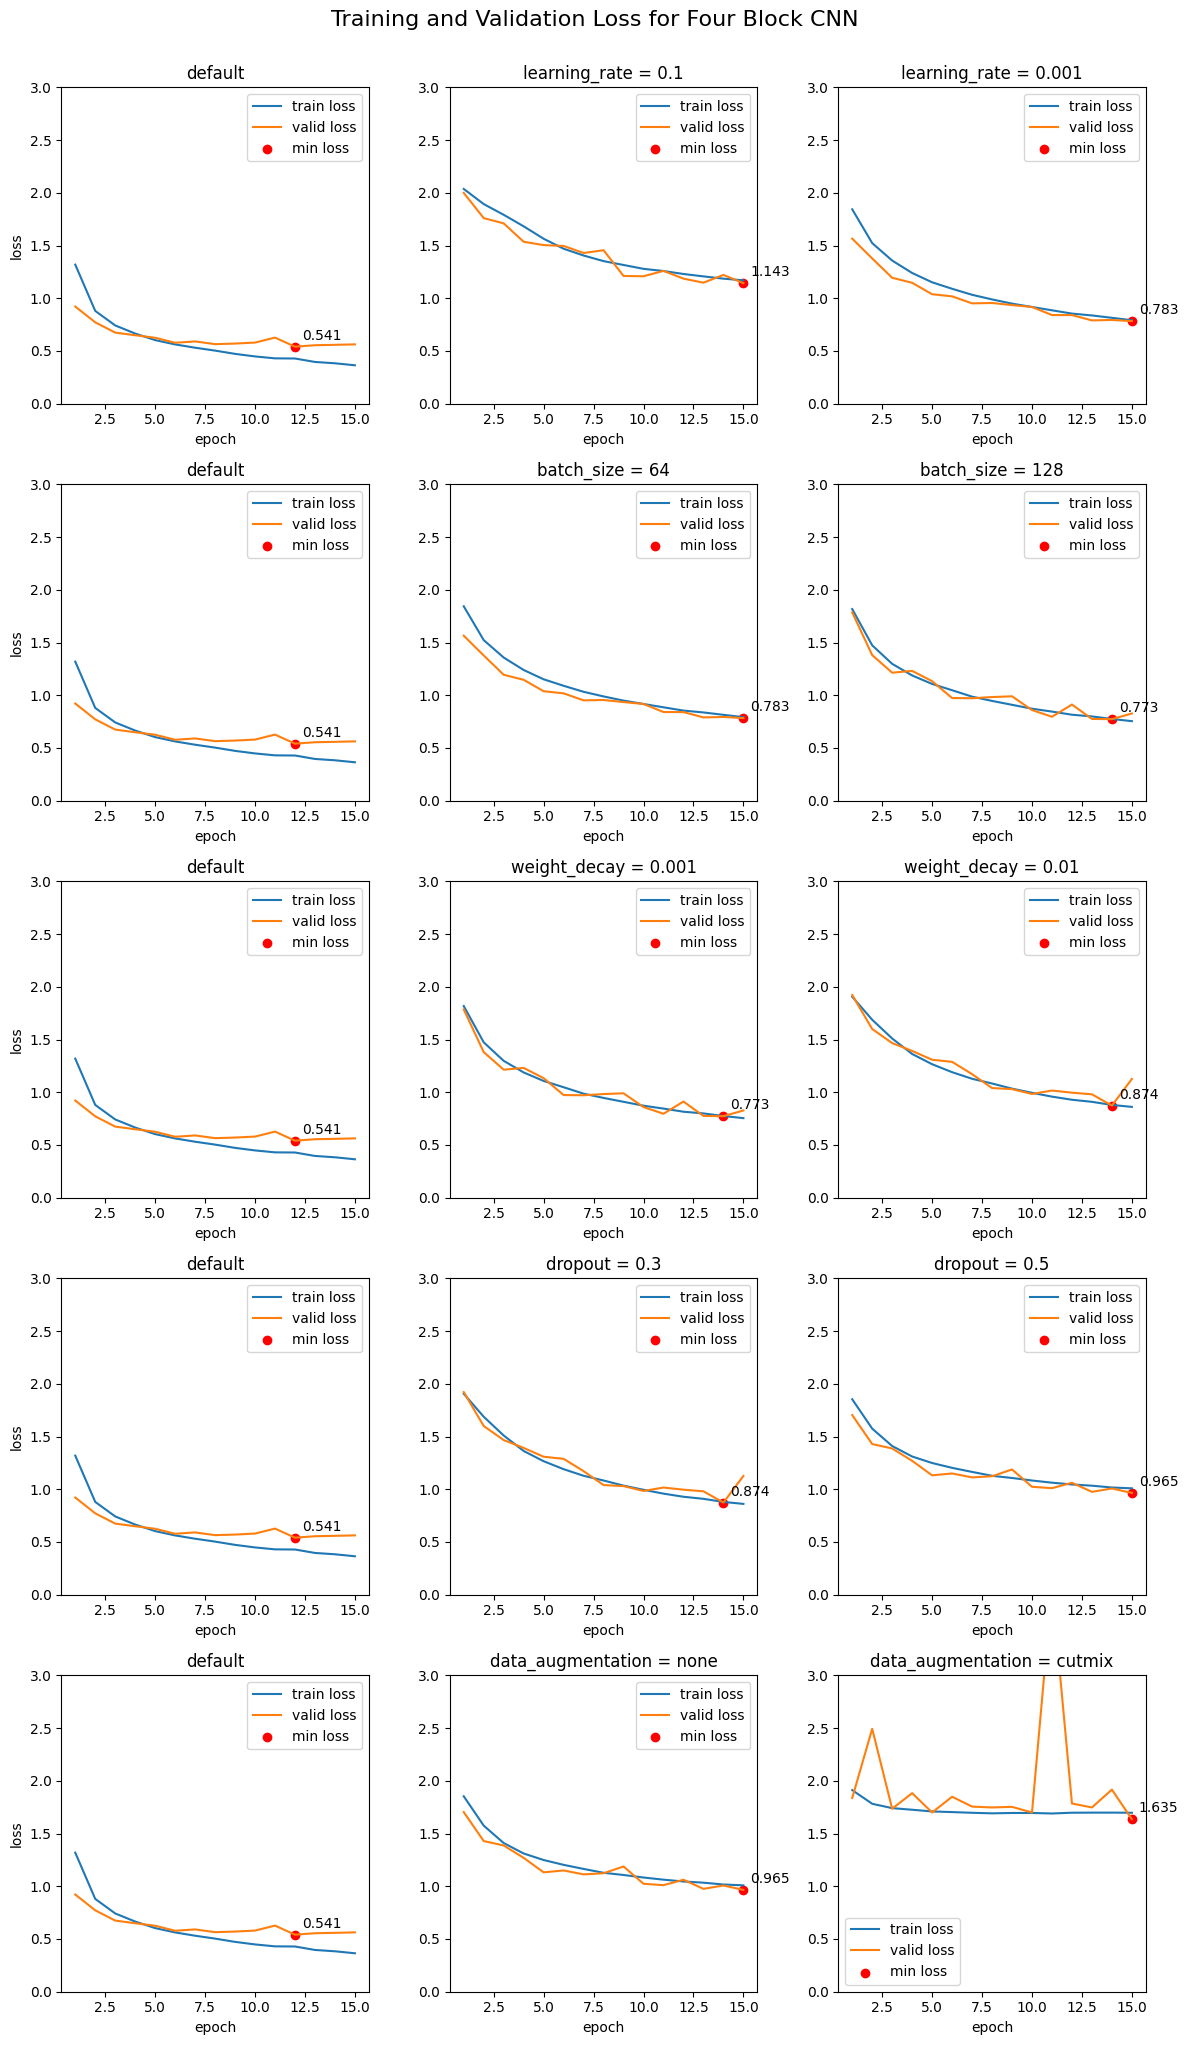

In [ ]:
ts_default_four = 1774634170
ts_default_ghostnet = 1774290736
ts_default_resnet = 1773854727

exp = exp[(exp["model"] == "four_block") & (pd.isna(exp["scheduler"]))]
cur = cur[cur["epoch"] <= 15]
ts_default_densenet = 1774088363
hyperparams = {
    "learning_rate": [0.1, 0.001],
    "batch_size": [64, 128],
    "weight_decay": [0.001, 0.01],
    "dropout": [0.3, 0.5],
    "data_augmentation": ["none", "cutmix"],
}
ts = []
for key, value in hyperparams.items():
    for v in value:
        ts.append(int(exp[exp[key] == v]["timestamp"].iloc[0]))

# zmienic
ts_default = ts_default_resnet

fig, axs = plt.subplots(5, 3, figsize=(12, 20))

i = 0
for key, value in hyperparams.items():
    cur_def = cur[cur["timestamp"] == ts_default]
    axs[i, 0].plot(cur_def["epoch"], cur_def["train_loss"], label="train loss")
    axs[i, 0].plot(cur_def["epoch"], cur_def["val_loss"], label="valid loss")
    min_def = cur_def.loc[cur_def["val_loss"].idxmin()]
    axs[i, 0].scatter(
        min_def["epoch"], min_def["val_loss"], color="red", label="min loss"
    )
    axs[i, 0].annotate(
        f'{min_def["val_loss"]:.3f}',
        (min_def["epoch"], min_def["val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
    )
    axs[i, 0].legend()
    axs[i, 0].set_ylim(0, 3)
    axs[i, 0].set_title("default")
    axs[i, 0].set_xlabel("epoch")
    axs[i, 0].set_ylabel("loss")

    cur_ts = cur[cur["timestamp"] == ts[i]]
    axs[i, 1].plot(cur_ts["epoch"], cur_ts["train_loss"], label="train loss")
    axs[i, 1].plot(cur_ts["epoch"], cur_ts["val_loss"], label="valid loss")
    min_row = cur_ts.loc[cur_ts["val_loss"].idxmin()]
    axs[i, 1].scatter(
        min_row["epoch"], min_row["val_loss"], color="red", label="min loss"
    )
    axs[i, 1].annotate(
        f'{min_row["val_loss"]:.3f}',
        (min_row["epoch"], min_row["val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
    )
    axs[i, 1].legend()
    axs[i, 1].set_title(f"{key} = {value[0]}")
    axs[i, 1].set_ylim(0, 3)
    axs[i, 1].set_xlabel("epoch")

    cur_ts2 = cur[cur["timestamp"] == ts[i + 1]]
    axs[i, 2].plot(cur_ts2["epoch"], cur_ts2["train_loss"], label="train loss")
    axs[i, 2].plot(cur_ts2["epoch"], cur_ts2["val_loss"], label="valid loss")
    min_row2 = cur_ts2.loc[cur_ts2["val_loss"].idxmin()]
    axs[i, 2].scatter(
        min_row2["epoch"], min_row2["val_loss"], color="red", label="min loss"
    )
    axs[i, 2].annotate(
        f'{min_row2["val_loss"]:.3f}',
        (min_row2["epoch"], min_row2["val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
    )
    axs[i, 2].legend()
    axs[i, 2].set_title(f"{key} = {value[1]}")
    axs[i, 2].set_ylim(0, 3)
    axs[i, 2].set_xlabel("epoch")

    i += 1

plt.tight_layout()

# zmienic nazwe
fig.suptitle("Training and Validation Loss for Four Block CNN", fontsize=16, y=1.02)
plt.show()